# Robustness of ML Models on Breast Cancer Data Under Data Degradation
**Research Questions:**
- RQ1: How does model accuracy change as missing data increases from 0% to 30%?
- RQ2: Which model is most robust to Gaussian noise injection?
- RQ3: Does the choice of imputation strategy affect robustness?
- RQ4: How do linear vs tree-based models compare under 20% data degradation?
- RQ5: Is there a corruption threshold beyond which all models degrade significantly?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore')

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('XGBoost not available, using GradientBoosting instead')
    from sklearn.ensemble import GradientBoostingClassifier

import os
os.makedirs('figures', exist_ok=True)
os.makedirs('tables', exist_ok=True)

# Style
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = ['#2563EB', '#16A34A', '#DC2626', '#9333EA']
print('Setup complete.')

Setup complete.


## 1. Dataset Overview

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

summary = pd.DataFrame({
    'Samples': [len(X)],
    'Features': [X.shape[1]],
    'Malignant (0)': [(y == 0).sum()],
    'Benign (1)': [(y == 1).sum()],
    'Missing Values': [X.isnull().sum().sum()]
})
display(summary)
summary.to_csv('tables/dataset_summary.csv', index=False)
print('Saved: tables/dataset_summary.csv')

,Samples,Features,Malignant (0),Benign (1),Missing Values
0,569,30,212,357,0


Saved: tables/dataset_summary.csv


## 2. Model Setup & Helper Functions

In [3]:
def get_models():
    models = {
        'Logistic Reg.': LogisticRegression(max_iter=1000, random_state=42),
        'SVM': SVC(random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    }
    if HAS_XGB:
        models['XGBoost'] = XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0)
    else:
        models['GradBoost'] = GradientBoostingClassifier(random_state=42)
    return models

def inject_missing(X, rate, seed=0):
    rng = np.random.default_rng(seed)
    Xc = X.copy()
    mask = rng.random(Xc.shape) < rate
    Xc[mask] = np.nan
    return Xc

def inject_noise(X, std_scale, seed=0):
    rng = np.random.default_rng(seed)
    noise = rng.normal(0, X.std(axis=0) * std_scale, X.shape)
    return X + noise

def impute_and_scale(X_tr, X_te, strategy='mean'):
    imp = SimpleImputer(strategy=strategy)
    X_tr_i = imp.fit_transform(X_tr)
    X_te_i = imp.transform(X_te)
    sc = StandardScaler()
    return sc.fit_transform(X_tr_i), sc.transform(X_te_i)

def evaluate(model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    return accuracy_score(y_te, pred), f1_score(y_te, pred)

X_arr = X.values.astype(float)
X_tr0, X_te0, y_tr, y_te = train_test_split(X_arr, y, test_size=0.2, random_state=42, stratify=y)
print('Train/test split done:', X_tr0.shape, X_te0.shape)

Train/test split done: (455, 30) (114, 30)


## RQ1 — Accuracy vs. Missing Data Rate (0%–30%)

,Logistic Reg.,SVM,Random Forest,XGBoost
Missing Rate,,,,
0%,0.9825,0.9825,0.9561,0.9561
5%,0.9737,0.9737,0.9474,0.9386
10%,0.9649,0.9737,0.9298,0.9474
15%,0.9561,0.9737,0.9386,0.9474
20%,0.9474,0.9649,0.9298,0.9561
25%,0.9561,0.9649,0.9298,0.9561
30%,0.9561,0.9649,0.9298,0.9386


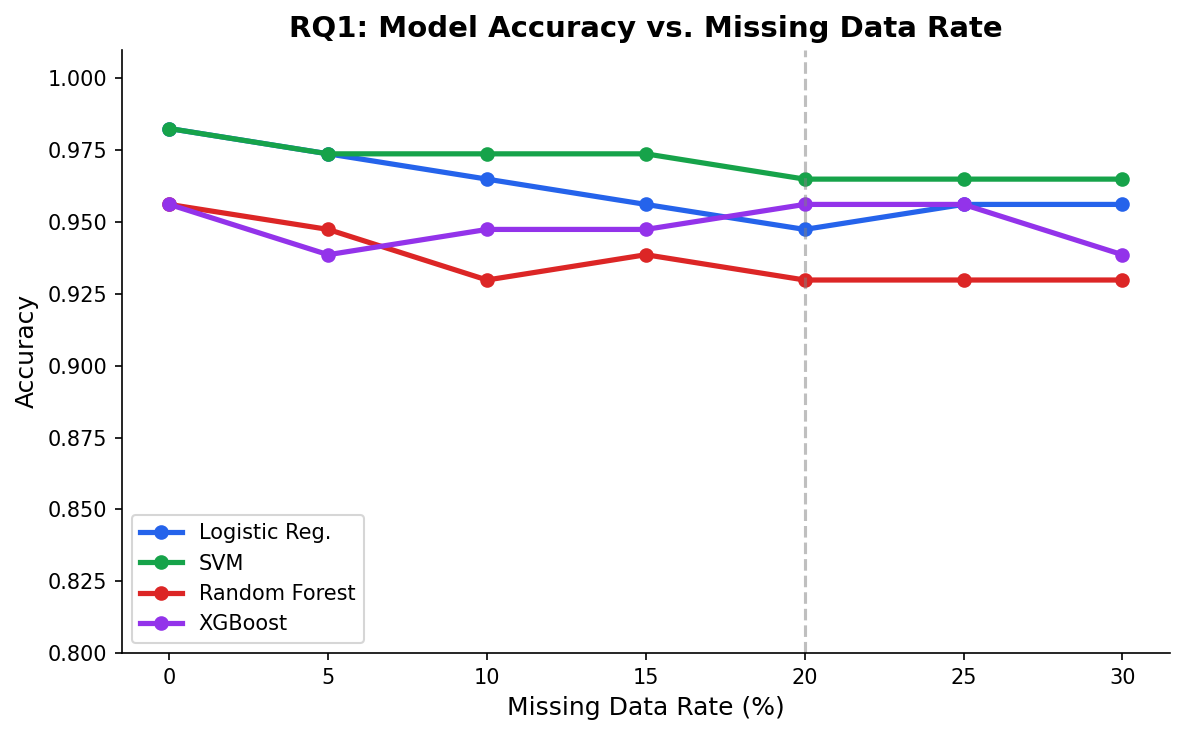

Saved: figures/rq1_missing_data.pdf


In [4]:
missing_rates = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
rq1_results = {name: [] for name in get_models()}

for rate in missing_rates:
    X_tr_m = inject_missing(X_tr0, rate)
    X_te_m = inject_missing(X_te0, rate)
    X_tr_s, X_te_s = impute_and_scale(X_tr_m, X_te_m)
    for name, model in get_models().items():
        acc, _ = evaluate(model, X_tr_s, X_te_s, y_tr, y_te)
        rq1_results[name].append(round(acc, 4))

rq1_df = pd.DataFrame(rq1_results, index=[f'{int(r*100)}%' for r in missing_rates])
rq1_df.index.name = 'Missing Rate'
display(rq1_df)
rq1_df.to_csv('tables/rq1_missing_data.csv')

fig, ax = plt.subplots(figsize=(8, 5))
for i, (name, vals) in enumerate(rq1_results.items()):
    ax.plot([r*100 for r in missing_rates], vals, marker='o', color=PALETTE[i], label=name, linewidth=2.5)
ax.set_xlabel('Missing Data Rate (%)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('RQ1: Model Accuracy vs. Missing Data Rate', fontsize=14, fontweight='bold')
ax.legend()
ax.set_ylim(0.8, 1.01)
ax.axvline(x=20, color='gray', linestyle='--', alpha=0.5, label='20% threshold')
plt.tight_layout()
plt.savefig('figures/rq1_missing_data.pdf', bbox_inches='tight')
plt.show()
print('Saved: figures/rq1_missing_data.pdf')

## RQ2 — Robustness to Gaussian Noise

,Logistic Reg.,SVM,Random Forest,XGBoost
Noise Std Scale,,,,
0.0,0.9825,0.9825,0.9561,0.9561
0.1,0.9737,0.9737,0.9474,0.9474
0.25,0.9561,0.9649,0.9386,0.9561
0.5,0.9737,0.9561,0.9298,0.9474
0.75,0.9649,0.9561,0.9474,0.9386
1.0,0.9561,0.9474,0.9298,0.9211
1.5,0.9474,0.9561,0.9211,0.9035


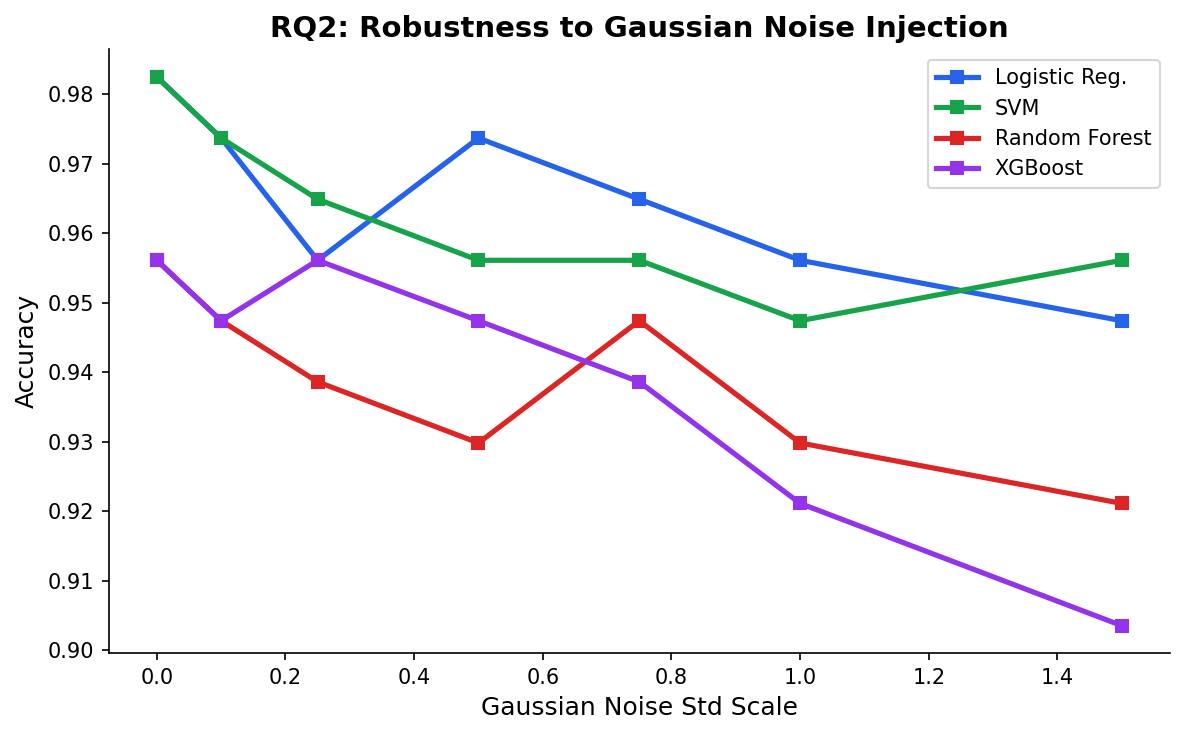

Saved: figures/rq2_noise_robustness.pdf


In [5]:
noise_levels = [0.0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.5]
rq2_results = {name: [] for name in get_models()}

sc_base = StandardScaler().fit(X_tr0)
X_tr_sc = sc_base.transform(X_tr0)
X_te_sc = sc_base.transform(X_te0)

for lvl in noise_levels:
    X_tr_n = inject_noise(X_tr_sc, lvl)
    X_te_n = inject_noise(X_te_sc, lvl)
    for name, model in get_models().items():
        acc, _ = evaluate(model, X_tr_n, X_te_n, y_tr, y_te)
        rq2_results[name].append(round(acc, 4))

rq2_df = pd.DataFrame(rq2_results, index=[str(l) for l in noise_levels])
rq2_df.index.name = 'Noise Std Scale'
display(rq2_df)
rq2_df.to_csv('tables/rq2_noise_robustness.csv')

fig, ax = plt.subplots(figsize=(8, 5))
for i, (name, vals) in enumerate(rq2_results.items()):
    ax.plot(noise_levels, vals, marker='s', color=PALETTE[i], label=name, linewidth=2.5)
ax.set_xlabel('Gaussian Noise Std Scale', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('RQ2: Robustness to Gaussian Noise Injection', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figures/rq2_noise_robustness.pdf', bbox_inches='tight')
plt.show()
print('Saved: figures/rq2_noise_robustness.pdf')

## RQ3 — Impact of Imputation Strategy

,Imputation,Model,Accuracy,F1
0,mean,Logistic Reg.,0.9474,0.9577
1,mean,SVM,0.9649,0.9722
2,mean,Random Forest,0.9298,0.9437
3,mean,XGBoost,0.9561,0.9650
4,median,Logistic Reg.,0.9474,0.9577
5,median,SVM,0.9561,0.9650
6,median,Random Forest,0.9211,0.9371
7,median,XGBoost,0.9474,0.9577
8,most_frequent,Logistic Reg.,0.9386,0.9510
9,most_frequent,SVM,0.9474,0.9583


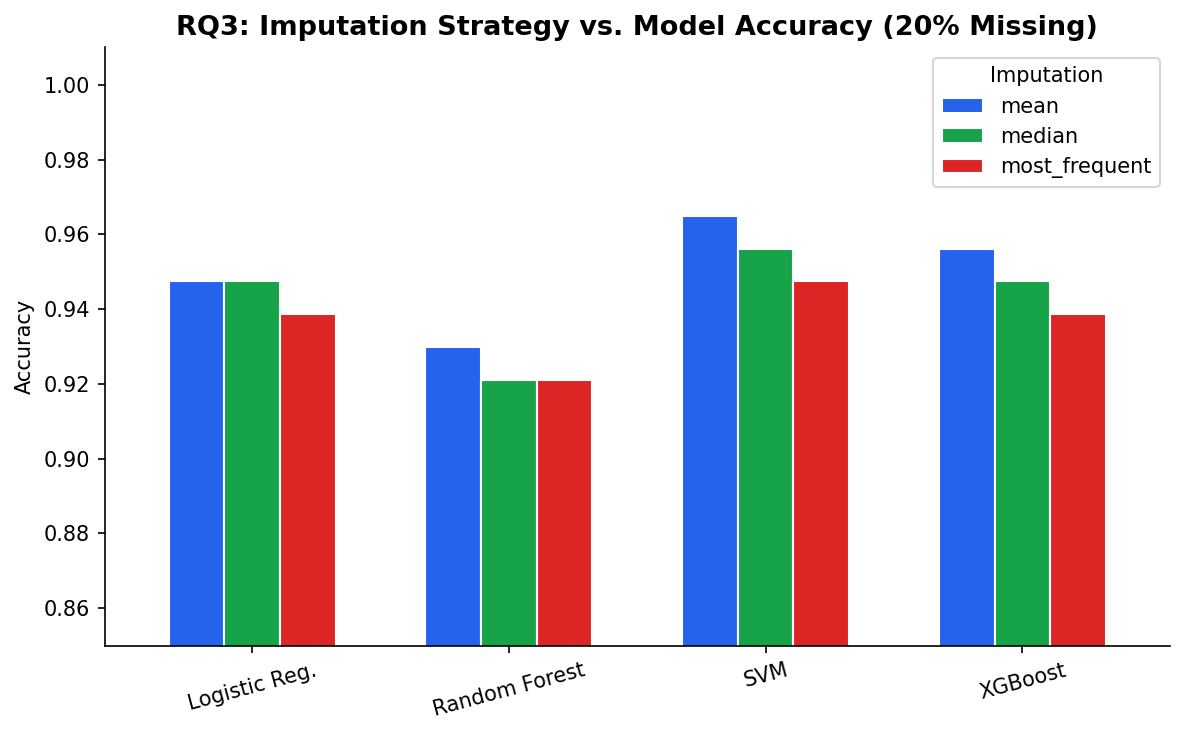

Saved: figures/rq3_imputation.pdf


In [6]:
imputation_strategies = ['mean', 'median', 'most_frequent']
missing_rate = 0.20
rq3_results = []

X_tr_m = inject_missing(X_tr0, missing_rate)
X_te_m = inject_missing(X_te0, missing_rate)

for strategy in imputation_strategies:
    X_tr_s, X_te_s = impute_and_scale(X_tr_m, X_te_m, strategy=strategy)
    for name, model in get_models().items():
        acc, f1 = evaluate(model, X_tr_s, X_te_s, y_tr, y_te)
        rq3_results.append({'Imputation': strategy, 'Model': name, 'Accuracy': round(acc,4), 'F1': round(f1,4)})

rq3_df = pd.DataFrame(rq3_results)
display(rq3_df)
rq3_df.to_csv('tables/rq3_imputation.csv', index=False)

pivot = rq3_df.pivot(index='Model', columns='Imputation', values='Accuracy')
fig, ax = plt.subplots(figsize=(8, 5))
pivot.plot(kind='bar', ax=ax, color=['#2563EB','#16A34A','#DC2626'], edgecolor='white', width=0.65)
ax.set_title('RQ3: Imputation Strategy vs. Model Accuracy (20% Missing)', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_xlabel('')
ax.set_ylim(0.85, 1.01)
ax.legend(title='Imputation')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('figures/rq3_imputation.pdf', bbox_inches='tight')
plt.show()
print('Saved: figures/rq3_imputation.pdf')

## RQ4 — Linear vs Tree-Based Models at 20% Degradation

,Model,Type,Accuracy,F1
0,Logistic Reg.,Linear,0.9474,0.9577
1,SVM,Linear,0.9649,0.9722
2,Random Forest,Tree-Based,0.9298,0.9437
3,XGBoost,Tree-Based,0.9561,0.9650


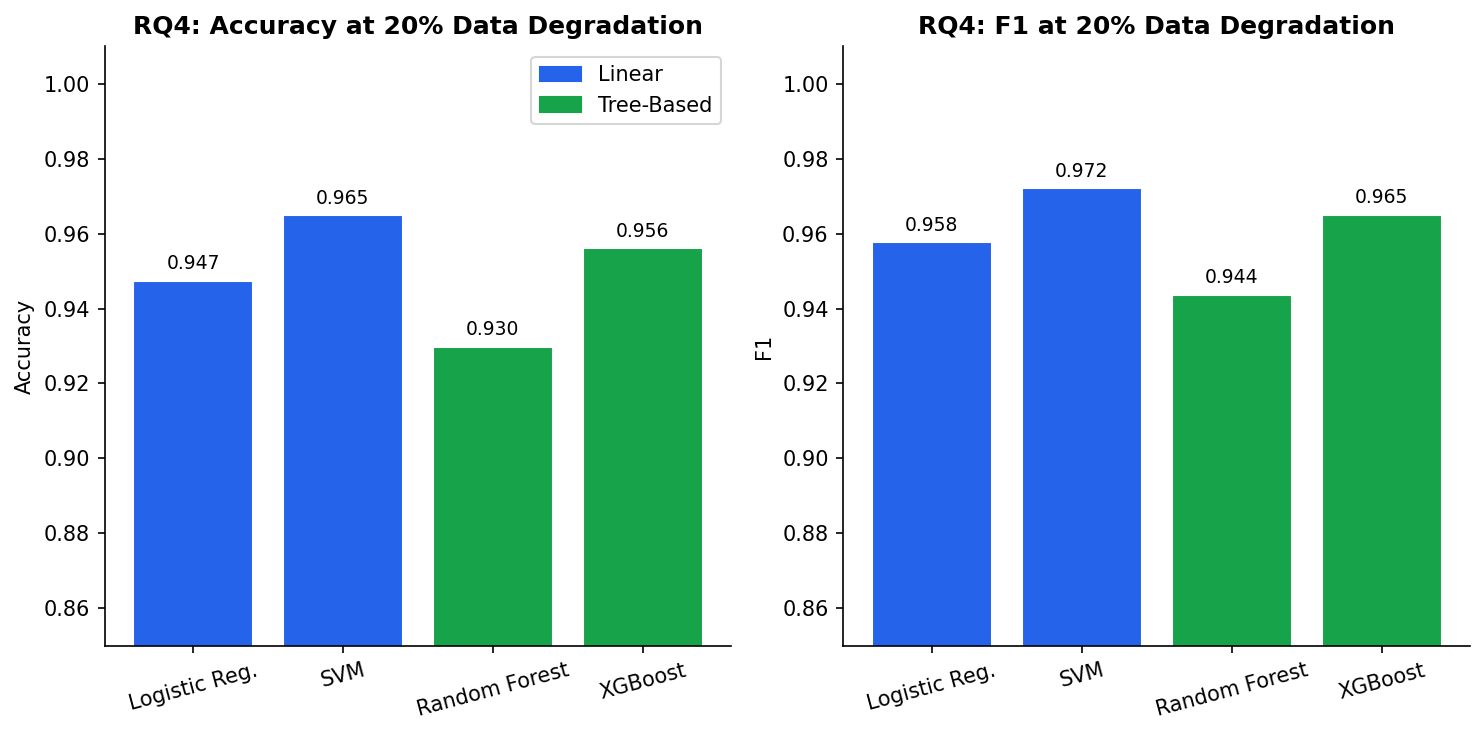

Saved: figures/rq4_linear_vs_tree.pdf


In [7]:
X_tr_m = inject_missing(X_tr0, 0.20)
X_te_m = inject_missing(X_te0, 0.20)
X_tr_s, X_te_s = impute_and_scale(X_tr_m, X_te_m)

rq4_results = []
for name, model in get_models().items():
    acc, f1 = evaluate(model, X_tr_s, X_te_s, y_tr, y_te)
    mtype = 'Linear' if name in ['Logistic Reg.', 'SVM'] else 'Tree-Based'
    rq4_results.append({'Model': name, 'Type': mtype, 'Accuracy': round(acc,4), 'F1': round(f1,4)})

rq4_df = pd.DataFrame(rq4_results)
display(rq4_df)
rq4_df.to_csv('tables/rq4_linear_vs_tree.csv', index=False)

colors = ['#2563EB' if t=='Linear' else '#16A34A' for t in rq4_df['Type']]
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, metric in zip(axes, ['Accuracy', 'F1']):
    bars = ax.bar(rq4_df['Model'], rq4_df[metric], color=colors, edgecolor='white')
    ax.set_title(f'RQ4: {metric} at 20% Data Degradation', fontsize=12, fontweight='bold')
    ax.set_ylim(0.85, 1.01)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
legend_handles = [mpatches.Patch(color='#2563EB', label='Linear'), mpatches.Patch(color='#16A34A', label='Tree-Based')]
axes[0].legend(handles=legend_handles)
plt.tight_layout()
plt.savefig('figures/rq4_linear_vs_tree.pdf', bbox_inches='tight')
plt.show()
print('Saved: figures/rq4_linear_vs_tree.pdf')

## RQ5 — Corruption Threshold Analysis

,Logistic Reg.,SVM,Random Forest,XGBoost
Corruption Rate,,,,
0%,0.9825,0.9825,0.9561,0.9561
5%,0.9737,0.9737,0.9474,0.9386
10%,0.9649,0.9737,0.9298,0.9474
15%,0.9561,0.9737,0.9386,0.9474
20%,0.9474,0.9649,0.9298,0.9561
25%,0.9561,0.9649,0.9298,0.9561
30%,0.9561,0.9649,0.9298,0.9386
40%,0.9737,0.9737,0.9298,0.9474
50%,0.9298,0.9298,0.9211,0.9211


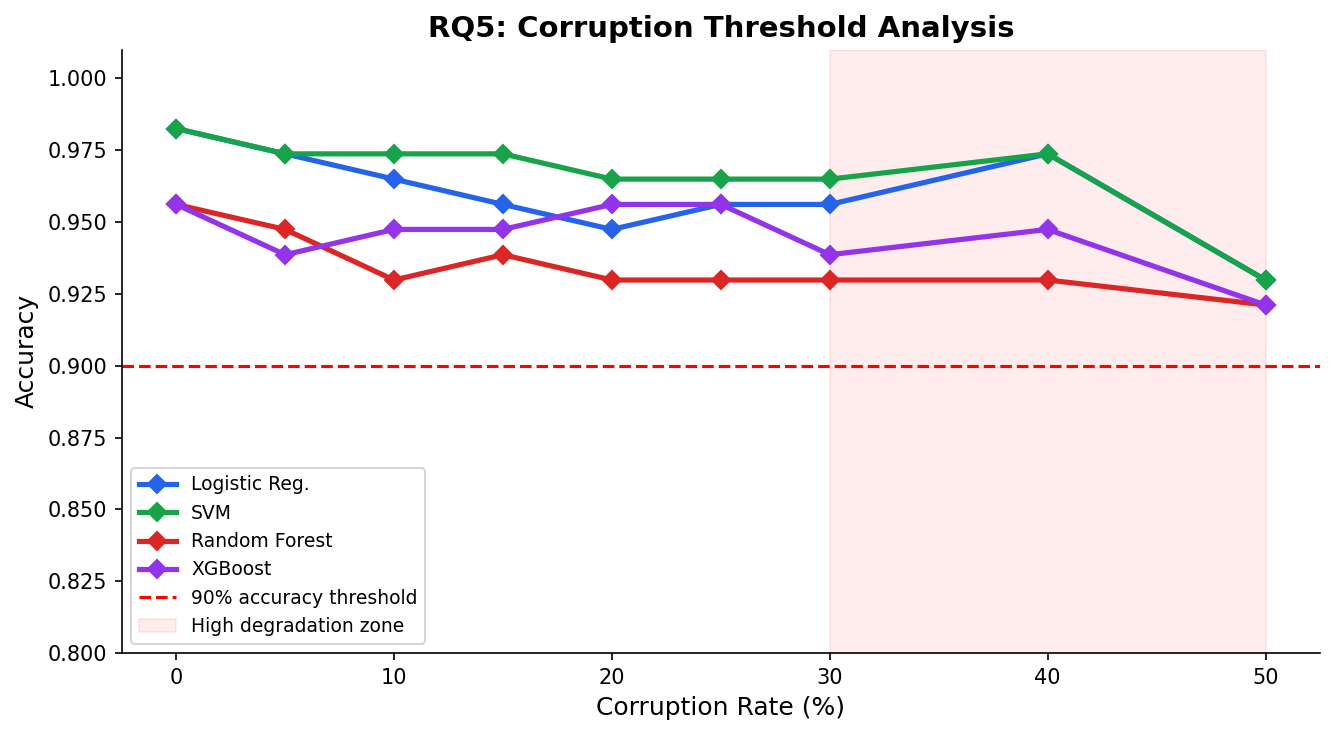

Saved: figures/rq5_threshold.pdf


In [8]:
corruption_rates = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
rq5_results = {name: [] for name in get_models()}

for rate in corruption_rates:
    X_tr_m = inject_missing(X_tr0, rate)
    X_te_m = inject_missing(X_te0, rate)
    X_tr_s, X_te_s = impute_and_scale(X_tr_m, X_te_m)
    for name, model in get_models().items():
        acc, _ = evaluate(model, X_tr_s, X_te_s, y_tr, y_te)
        rq5_results[name].append(round(acc, 4))

rq5_df = pd.DataFrame(rq5_results, index=[f'{int(r*100)}%' for r in corruption_rates])
rq5_df.index.name = 'Corruption Rate'
display(rq5_df)
rq5_df.to_csv('tables/rq5_threshold.csv')

fig, ax = plt.subplots(figsize=(9, 5))
for i, (name, vals) in enumerate(rq5_results.items()):
    ax.plot([r*100 for r in corruption_rates], vals, marker='D', color=PALETTE[i], label=name, linewidth=2.5)
ax.axhline(y=0.90, color='red', linestyle='--', linewidth=1.5, label='90% accuracy threshold')
ax.fill_between([30, 50], 0.8, 1.01, alpha=0.07, color='red', label='High degradation zone')
ax.set_xlabel('Corruption Rate (%)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('RQ5: Corruption Threshold Analysis', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0.8, 1.01)
plt.tight_layout()
plt.savefig('figures/rq5_threshold.pdf', bbox_inches='tight')
plt.show()
print('Saved: figures/rq5_threshold.pdf')

## Summary Table — All Models, All Conditions

Condition,10% Missing,20% Missing,30% Missing,Clean
Model,,,,
Logistic Reg.,0.9649,0.9474,0.9561,0.9825
Random Forest,0.9298,0.9298,0.9298,0.9561
SVM,0.9737,0.9649,0.9649,0.9825
XGBoost,0.9474,0.9561,0.9386,0.9561


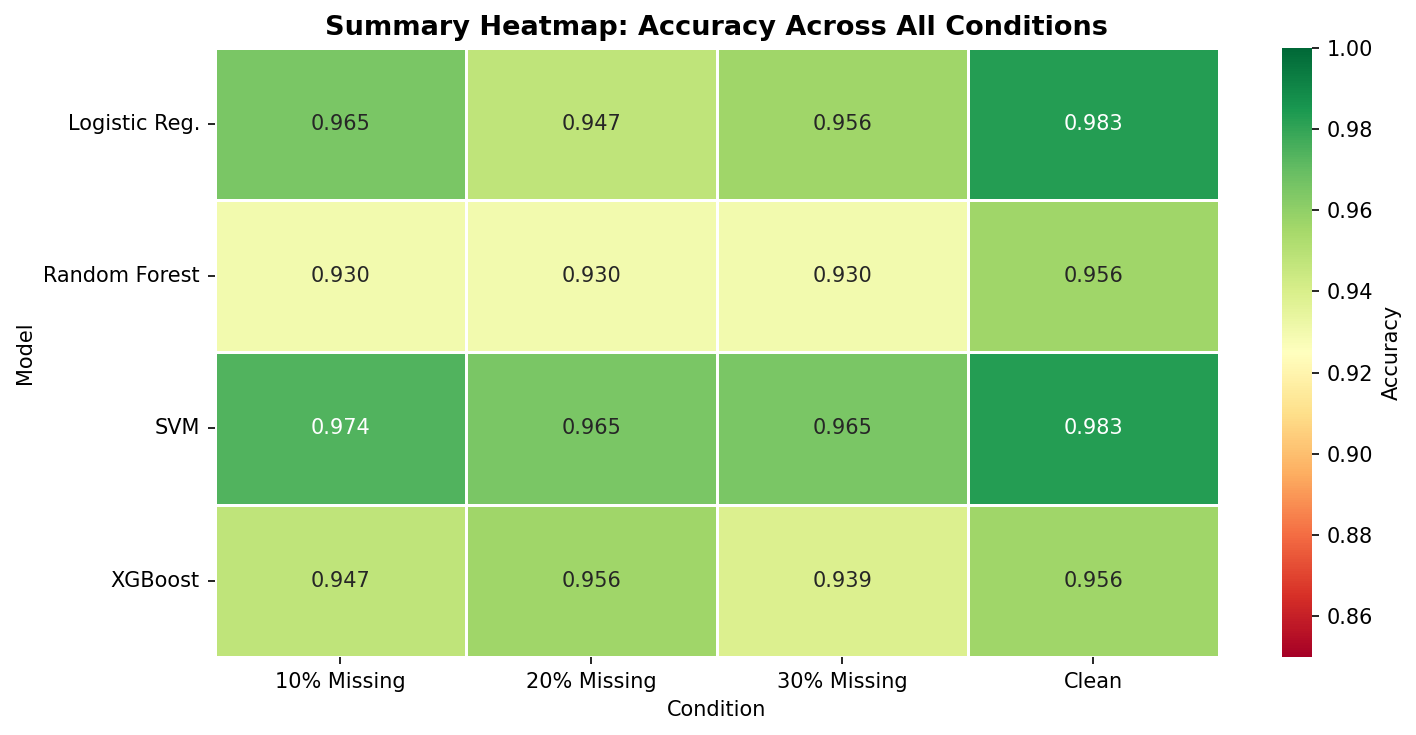

Saved: figures/summary_heatmap.pdf

All figures and tables saved successfully!


In [9]:
rows = []
conditions = [(0.0,'Clean'),(0.10,'10% Missing'),(0.20,'20% Missing'),(0.30,'30% Missing')]
for rate, label in conditions:
    X_tr_m = inject_missing(X_tr0, rate)
    X_te_m = inject_missing(X_te0, rate)
    X_tr_s, X_te_s = impute_and_scale(X_tr_m, X_te_m)
    for name, model in get_models().items():
        acc, f1 = evaluate(model, X_tr_s, X_te_s, y_tr, y_te)
        rows.append({'Condition': label, 'Model': name, 'Accuracy': round(acc,4), 'F1': round(f1,4)})

summary_df = pd.DataFrame(rows)
pivot_summary = summary_df.pivot_table(index='Model', columns='Condition', values='Accuracy')
display(pivot_summary)
summary_df.to_csv('tables/summary_all_conditions.csv', index=False)
pivot_summary.to_csv('tables/summary_pivot.csv')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot_summary, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax,
            linewidths=0.5, cbar_kws={'label':'Accuracy'}, vmin=0.85, vmax=1.0)
ax.set_title('Summary Heatmap: Accuracy Across All Conditions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/summary_heatmap.pdf', bbox_inches='tight')
plt.show()
print('Saved: figures/summary_heatmap.pdf')
print('\nAll figures and tables saved successfully!')